# Overview 

This notebook is for catalog-paper sample description figures, not Hα metric analysis.

Planned contents:

- sky distribution of Hα sample
  - Virgo filament / cluster context
- sfr - mstar plot
- histogram comparing halpha vs parent catalog in terms of:
  - distance
  - stellar mass
  - SFR
  - morphology/type
  - environment class
- filters
- 


In [4]:
import os
from matplotlib import pyplot as plt
import numpy as np
from astropy.table import Table
import glob


homedir = os.getenv("HOME")
plotdir = homedir + "/research/Virgo/hapypost/plots/"

# Sky Plot

table directory = /Users/rfinn/research/Virgo/tables-north/v2/


CO galaxies with no Halpha
VFID0520
VFID0606
VFID0787
VFID1536
VFID1899
VFID1977
VFID2819
VFID2909
VFID3245
VFID3540
VFID4878
VFID5835
VFID5855
VFID6025
VFID6148
VFID6236
VFID6340
VFID6582


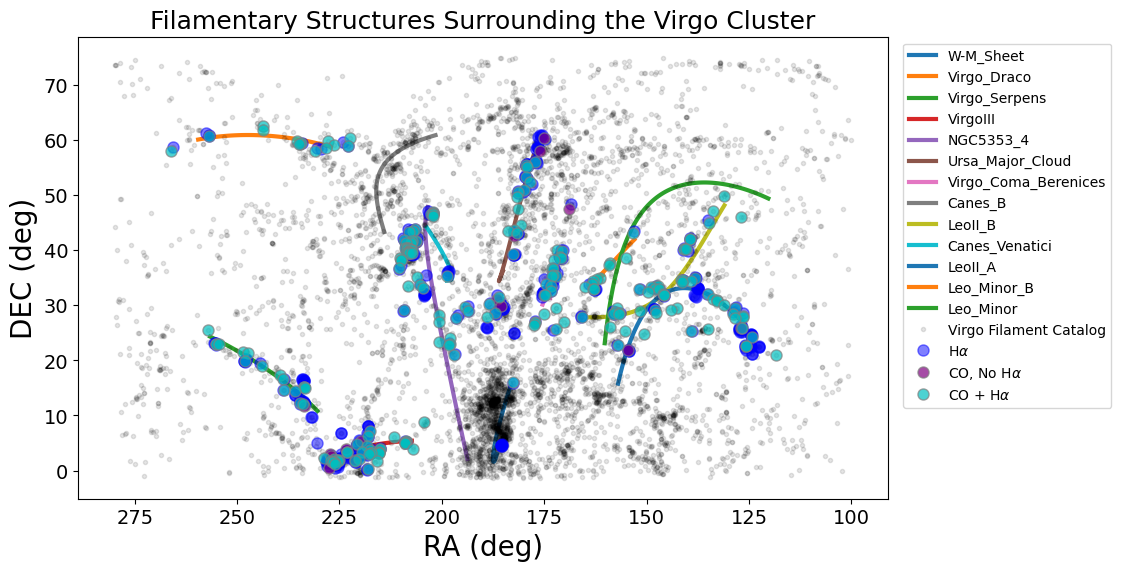

In [20]:
%run ../scripts/plot_sample_overview.py --tabledir ~/research/Virgo/tables-north/v2/ --plotdir $plotdir
plot_halpha_sky_positions(v, args.plotdir)
plt.show()

### working on resolving missing CO galaxies - they were observed!

- most of these are missing due to a problem in `get_cutouts` and the `_weight_ok` function which was too stringent.

In [11]:
np.sum(v.main["COflag"] & v.main['HAobsflag'])

242

In [17]:
flag = v.main["COflag"] & v.main['HAobsflag'] & ~v.halpha["HAPY_HAS_OBS"] 

In [18]:
v.main['VFID'][flag]

VFID0520
VFID0606
VFID0787
VFID1536
VFID1899
VFID1977
VFID2819
VFID2909
VFID3245
VFID3540
VFID4878


# SFR-Mstar Sample Overview

table directory = /Users/rfinn/research/Virgo/tables-north/v2/


/Users/rfinn/github/hapypost/scripts/plot_sample_overview.py:109: RuntimeWarning: divide by zero encountered in log10
  x = np.log10(np.array(v.cigale['bayes.stellar.m_star'], dtype=float))
/Users/rfinn/github/hapypost/scripts/plot_sample_overview.py:109: RuntimeWarning: invalid value encountered in log10
  x = np.log10(np.array(v.cigale['bayes.stellar.m_star'], dtype=float))
/Users/rfinn/github/hapypost/scripts/plot_sample_overview.py:110: RuntimeWarning: divide by zero encountered in log10
  y = np.log10(np.array(v.cigale['bayes.sfh.sfr'], dtype=float))
/Users/rfinn/github/hapypost/scripts/plot_sample_overview.py:110: RuntimeWarning: invalid value encountered in log10
  y = np.log10(np.array(v.cigale['bayes.sfh.sfr'], dtype=float))


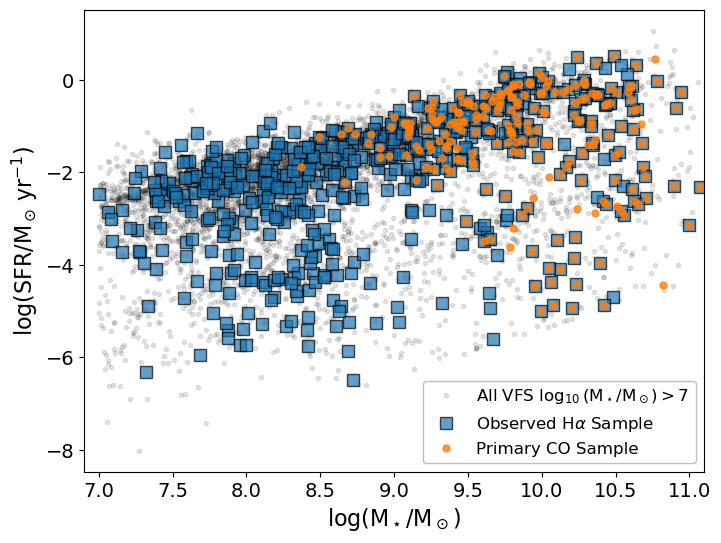

In [32]:
%run ../scripts/plot_sample_overview.py --tabledir ~/research/Virgo/tables-north/v2/ --plotdir $plotdir
plot_sfr_mstar_sample(v, args.plotdir)
plt.show()

# Redshift Distribution

table directory = /Users/rfinn/research/Virgo/tables-north/v2/


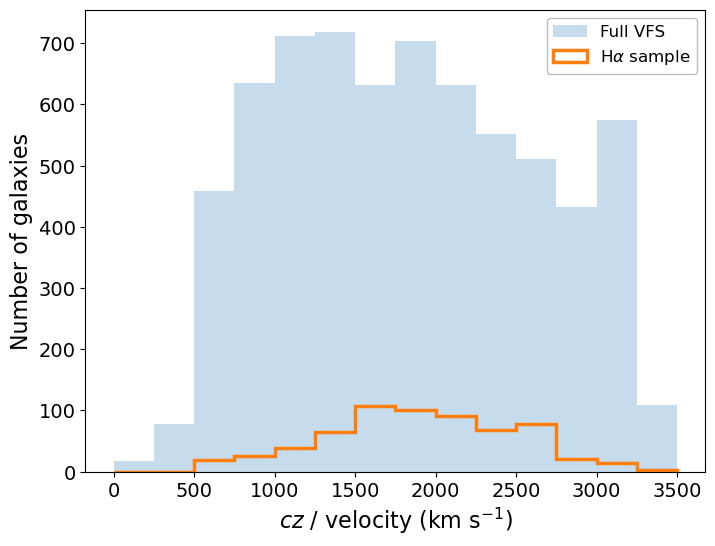

In [35]:
%run ../scripts/plot_sample_overview.py --tabledir ~/research/Virgo/tables-north/v2/ --plotdir $plotdir
plot_redshift_distribution(v, args.plotdir)
plt.show()

# Environment Distribution

table directory = /Users/rfinn/research/Virgo/tables-north/v2/


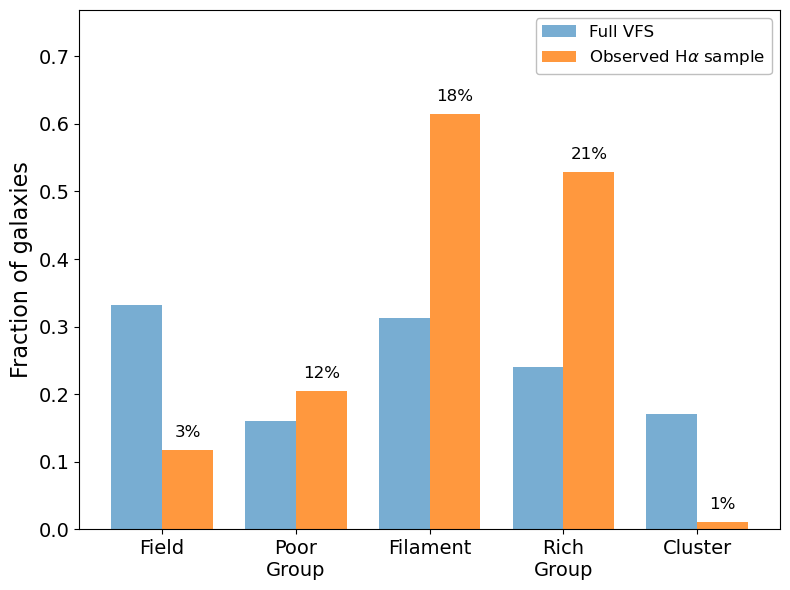

In [46]:
%run ../scripts/plot_sample_overview.py --tabledir ~/research/Virgo/tables-north/v2/ --plotdir $plotdir
plot_environment_distribution(v, args.plotdir, show=True)
#plt.show()

# Filters

In [7]:
# redoing after standardizing filters


filter_dir = homedir+'/research/Halpha_filters/fits_versions/'
hafilters = glob.glob(filter_dir+'*Ha*.fits')
plt.figure(figsize=(10,4))
plt.subplots_adjust(bottom=.15)
xlab = "Wavelength ($\AA$)"
ylab = "Transmission (%)"

# plot halpha filters
hafilters = ['BOK90prime-Ha+4nm.fits',
             'HDI-Ha+4nm.fits',
             'MOS-Ha+4nm.fits',
             'WFC-Ha-197.fits',
             'WFC-Ha-227.fits']

rfilters = ['BOK90prime-BASSr.fits',
             'HDI-SDSSr.fits',
             'HDI-HarrisR.fits',
             'MOS-SDSSr.fits',
             'MOS-HarrisR.fits',
             'WFC-SDSSr-214.fits',
            ]


plt.subplot(1,2,1)
for i,f in enumerate(hafilters):
    tab = Table.read(os.path.join(filter_dir,f))
    plt.plot(tab['wavelength'],tab['transmission'],label=os.path.basename(f).replace('.fits','').replace('BOK',''))
    #print(halabels[i],f"{integrate_filter(wav,T):.2f}")
plt.xlabel(xlab,fontsize=14)
plt.ylabel(ylab,fontsize=14)
plt.title("H-alpha Filters")
plt.xlim(6450,6800)
#plt.ylim(-5,102)
plt.legend(loc='lower right',fontsize=10)


plt.subplot(1,2,2)
# plot halpha filters
for i,f in enumerate(rfilters):
    tab = Table.read(os.path.join(filter_dir,f))
    plt.plot(tab['wavelength'],tab['transmission'],label=os.path.basename(f).replace('.fits','').replace('BOK',''))
    #print(rlabels[i],f"{integrate_filter(wav,T):.2f}")
plt.legend(loc='lower right',fontsize=10)
plt.xlabel(xlab,fontsize=14)
#plt.ylabel(ylab,fontsize=16)
plt.xlim(5000,8750)
plt.ylim(-5,102)
plt.title("Broad-band Filters")

# plot wavelength of halpha
lambda0 = 6563
vr_virgo = 2000
#plt.axvline(x=6625)
plt.savefig(homedir+'/research/Virgo/plots/halpha/filter_traces_v2.png')
plt.savefig(homedir+'/research/Virgo/plots/halpha/filter_traces_v2.pdf')


NameError: name 'glob' is not defined

Running on Rose's computer
tabledir =  /Users/rfinn/research/Virgo/tables-north/v2/


/Users/rfinn/github/havirgo/python/ha-paper1.py:53: RuntimeWarning: invalid value encountered in divide
  snr_flag = np.abs(self.halpha['HF_TOT']/self.halpha['HF_TOT_ERR']) > 3


mean(med) diff b/w R and Halpha PSF = 0.03(0.03) +/- 0.19
H FWHM - R FWHM = 0.03 +/- 0.19


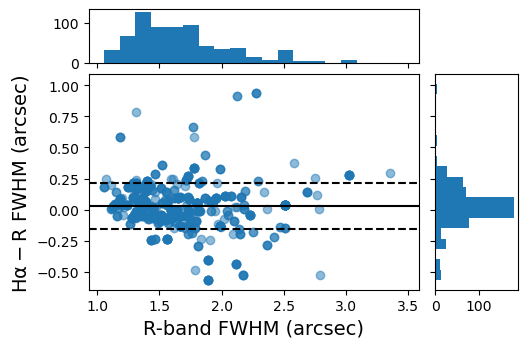

In [6]:
%run ~/github/havirgo/python/ha-paper1.py
h.plot_fwhm_r_h()